<a href="https://colab.research.google.com/github/andreelzs/Linguagens-de-programacao/blob/main/analise_ecommerce_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático 2: Análise de Desempenho e Limpeza de Dados de E-commerce

## Célula 1: Configuração do Ambiente e Criação dos Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
np.random.seed(101)

n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

df_ecommerce = pd.concat([df_ecommerce, df_ecommerce.iloc[:10]], ignore_index=True)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")
df_ecommerce.head()

Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


## Tarefa 1: Limpeza e Preparação dos Dados

In [2]:
print("ANTES DA LIMPEZA")
print(f"Total de linhas: {len(df_ecommerce)}")
print(f"\nLinhas duplicadas: {df_ecommerce.duplicated().sum()}")
print(f"\nValores nulos por coluna:")
print(df_ecommerce.isnull().sum())

ANTES DA LIMPEZA
Total de linhas: 210

Linhas duplicadas: 10

Valores nulos por coluna:
ID_Cliente           0
Categoria            0
Valor_Gasto          0
Avaliacao_Compra    22
Idade_Cliente        0
dtype: int64


In [3]:
df_ecommerce = df_ecommerce.drop_duplicates()

print(f"\nAPÓS REMOVER DUPLICATAS")
print(f"Total de linhas: {len(df_ecommerce)}")
print(f"Linhas duplicadas removidas: {210 - len(df_ecommerce)}")


APÓS REMOVER DUPLICATAS
Total de linhas: 200
Linhas duplicadas removidas: 10


In [4]:
print(f"\nValores nulos ANTES do preenchimento:")
print(df_ecommerce.isnull().sum())

mediana_avaliacao = df_ecommerce['Avaliacao_Compra'].median()
df_ecommerce['Avaliacao_Compra'] = df_ecommerce['Avaliacao_Compra'].fillna(mediana_avaliacao)

print(f"\nMediana de Avaliacao_Compra: {mediana_avaliacao}")
print(f"\nValores nulos APÓS o preenchimento:")
print(df_ecommerce.isnull().sum())


Valores nulos ANTES do preenchimento:
ID_Cliente           0
Categoria            0
Valor_Gasto          0
Avaliacao_Compra    21
Idade_Cliente        0
dtype: int64

Mediana de Avaliacao_Compra: 4.0

Valores nulos APÓS o preenchimento:
ID_Cliente          0
Categoria           0
Valor_Gasto         0
Avaliacao_Compra    0
Idade_Cliente       0
dtype: int64


## Tarefa 2: Comparação por Categoria (Boxplot com Seaborn)

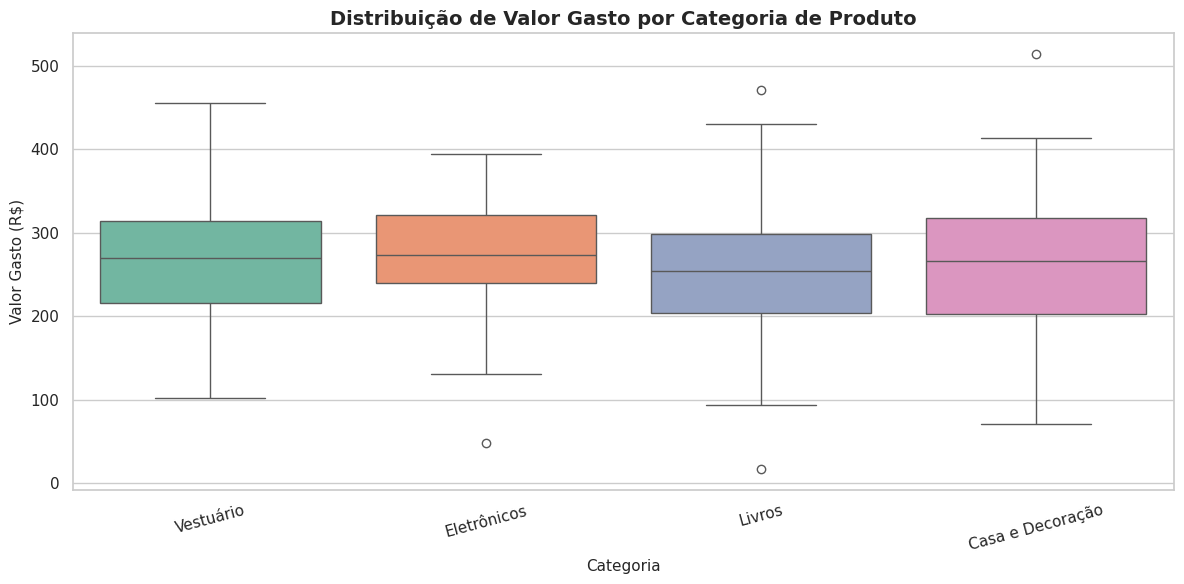

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_ecommerce, x='Categoria', y='Valor_Gasto', hue='Categoria', palette='Set2', legend=False, ax=ax)
ax.set_title('Distribuição de Valor Gasto por Categoria de Produto', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria', fontsize=11)
ax.set_ylabel('Valor Gasto (R$)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
print("ANÁLISE DE VALOR GASTO POR CATEGORIA")
print("=" * 60)
stats = df_ecommerce.groupby('Categoria')['Valor_Gasto'].agg(['count', 'mean', 'std', 'min', 'max'])
print(stats)

categoria_maior_variacao = stats['std'].idxmax()
print(f"\nCategoria com MAIOR variação (desvio padrão): {categoria_maior_variacao}")
print(f"Desvio padrão: {stats.loc[categoria_maior_variacao, 'std']:.2f}")

ANÁLISE DE VALOR GASTO POR CATEGORIA
                  count        mean        std     min     max
Categoria                                                     
Casa e Decoração     49  257.817143  88.942519   70.63  514.29
Eletrônicos          43  273.130465  71.303618   47.76  395.03
Livros               61  256.567869  81.135752   16.89  471.64
Vestuário            47  269.018936  77.837054  102.12  455.23

Categoria com MAIOR variação (desvio padrão): Casa e Decoração
Desvio padrão: 88.94


## Tarefa 3: Distribuição e Correlação

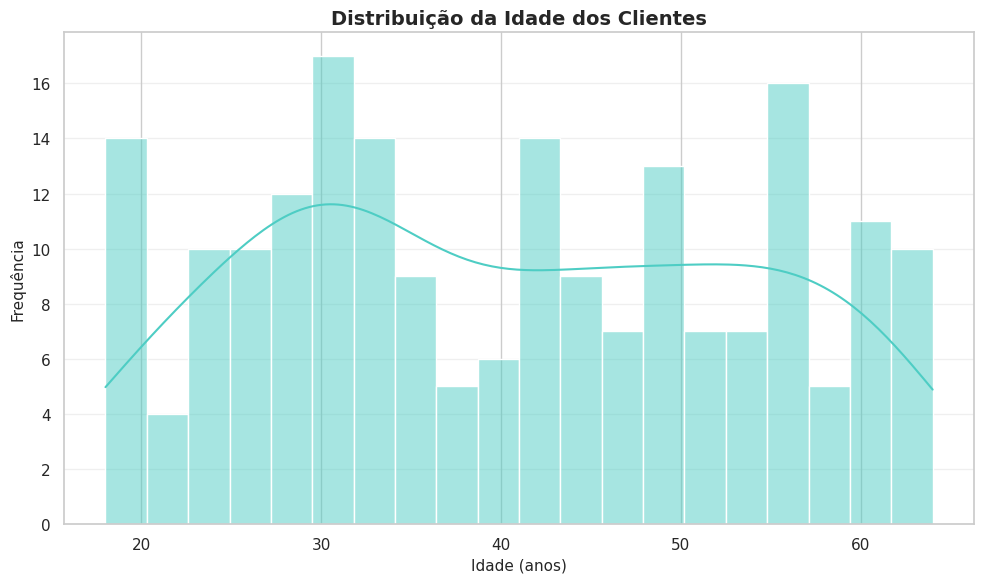

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_ecommerce, x='Idade_Cliente', kde=True, bins=20, color='#4ECDC4', ax=ax)
ax.set_title('Distribuição da Idade dos Clientes', fontsize=14, fontweight='bold')
ax.set_xlabel('Idade (anos)', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print("ESTATÍSTICAS DE IDADE")
print("=" * 60)
print(f"Idade mínima: {df_ecommerce['Idade_Cliente'].min()} anos")
print(f"Idade máxima: {df_ecommerce['Idade_Cliente'].max()} anos")
print(f"Idade média: {df_ecommerce['Idade_Cliente'].mean():.1f} anos")
print(f"Idade mediana: {df_ecommerce['Idade_Cliente'].median():.1f} anos")
print(f"Desvio padrão: {df_ecommerce['Idade_Cliente'].std():.1f} anos")

ESTATÍSTICAS DE IDADE
Idade mínima: 18 anos
Idade máxima: 64 anos
Idade média: 40.4 anos
Idade mediana: 40.0 anos
Desvio padrão: 13.4 anos


## Resumo Final

In [9]:
print("\n" + "=" * 70)
print("RESUMO DO EXERCÍCIO DE LIMPEZA E ANÁLISE")
print("=" * 70)

print(f"\n✓ TAREFA 1 - LIMPEZA DE DADOS")
print(f"  - Linhas duplicadas removidas: 10")
print(f"  - Total de linhas após limpeza: {len(df_ecommerce)}")
print(f"  - Valores nulos preenchidos em Avaliacao_Compra com mediana: {mediana_avaliacao}")

print(f"\n✓ TAREFA 2 - ANÁLISE POR CATEGORIA")
print(f"  - Categoria com maior variação: {categoria_maior_variacao}")
print(f"  - Desvio padrão: {stats.loc[categoria_maior_variacao, 'std']:.2f}")

print(f"\n✓ TAREFA 3 - DISTRIBUIÇÃO DE IDADE")
print(f"  - Idade média dos clientes: {df_ecommerce['Idade_Cliente'].mean():.1f} anos")
print(f"  - Distribuição: entre {df_ecommerce['Idade_Cliente'].min()} e {df_ecommerce['Idade_Cliente'].max()} anos")

print("\n" + "=" * 70)


RESUMO DO EXERCÍCIO DE LIMPEZA E ANÁLISE

✓ TAREFA 1 - LIMPEZA DE DADOS
  - Linhas duplicadas removidas: 10
  - Total de linhas após limpeza: 200
  - Valores nulos preenchidos em Avaliacao_Compra com mediana: 4.0

✓ TAREFA 2 - ANÁLISE POR CATEGORIA
  - Categoria com maior variação: Casa e Decoração
  - Desvio padrão: 88.94

✓ TAREFA 3 - DISTRIBUIÇÃO DE IDADE
  - Idade média dos clientes: 40.4 anos
  - Distribuição: entre 18 e 64 anos

